# Assignment 1 Overview {.unnumbered}

This notebook is the canonical Assignment 1 working file. It combines the assignment instructions, a cleaner solution pipeline, and local-first execution so `Run All` works without a Google Drive prompt.

## What this notebook is for

- Build a two-company SEC 10-K corpus for one NAICS vertical.
- Extract Item 7, Item 7A, and Item 8 for filing years 2020-2024.
- Create sentence chunks and TF-IDF features.
- Compare the two companies with cosine similarity and a PyTorch bag-of-words classifier.
- Produce the evidence needed for Q1-Q3 and the final business recommendation.

## Submission package

Submit the following on Blackboard:

1. A Word report in APA 7 format that answers Q1-Q3 and the business recommendation.
2. This executed notebook as an `.ipynb` file.
3. A separate AI disclosure document with prompts, outputs used, and validation notes.


## Reproducibility Standard

A strong submission should be executable top-to-bottom in a fresh local or Colab runtime.

- Define configuration once near the top.
- Save every major artifact before reusing it later.
- Show sample rows and diagnostics for every important DataFrame.
- Include the required tables and charts directly in the notebook.
- Make sure every claim in the Word report matches executed notebook output.

## Required evidence to show in the notebook

- `market_df`: company context table with market and return information.
- `filings_df`: the filing manifest used for download and extraction.
- `corpus_df`: one row per extracted section.
- `chunks_df`: sentence-level chunk corpus.
- Top-term comparison chart from TF-IDF.
- Cosine similarity chart by year and section.
- Classifier accuracy, confusion matrix, and a small misclassification table.



## Assignment Question Alignment

This solution notebook is organized to cover every required assignment question and the supporting evidence students need to show.

- Setup and market context support the company-selection requirement and the business framing.
- Corpus extraction and chunking support the reproducibility and corpus-construction requirements.
- TF-IDF, cosine similarity, and the classifier support Q1 and Q2.
- Top terms, market context, and error analysis support Q3 and the business recommendation.
- Every major DataFrame should be shown with `.head()`, `.info()`, `.describe()`, plus at least one meaningful visualization.


In [1]:
# If a package is missing in your environment, uncomment the next line and rerun this cell.
# %pip install -q yfinance beautifulsoup4 lxml seaborn nltk

import json
import random
import re
import time
from html import unescape
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
import torch
import torch.nn as nn
import yfinance as yf
from bs4 import BeautifulSoup
from nltk import download as nltk_download
from nltk.tokenize import sent_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 200)
sns.set_theme(style="whitegrid")

COMPANY_COLORS = {
    "Microsoft": "#7FBA00",
    "Oracle": "#C74634",
    "Alphabet": "#4285F4",
    "Apple": "#555555",
}


def palette_for_companies(order):
    return [COMPANY_COLORS.get(name, "#4C78A8") for name in order]


def palette_for_tickers(order):
    return [TICKER_COLORS.get(ticker, "#4C78A8") for ticker in order]


def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def find_repo_root(start: Optional[Path] = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() or (candidate / ".git").exists():
            return candidate
    return start


set_seed(42)
nltk_download("punkt") # Download the Punkt tokenizer models for sentence tokenization

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())


PyTorch version: 2.11.0+cu130
CUDA available: True


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\nakul\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [2]:
REPO_ROOT = find_repo_root()
ASSIGNMENT_DIR = REPO_ROOT / "deliverables-solutions" / "Assignments" / "outputs" / "M01_A_sol"
ASSIGNMENT_DIR.mkdir(parents=True, exist_ok=True)

# Google Drive version kept here as comments for future Colab use.
# from google.colab import drive
# drive.mount("/content/drive", force_remount=True)
# ASSIGNMENT_DIR = Path("/content/drive/MyDrive/assignment01")
# ASSIGNMENT_DIR.mkdir(parents=True, exist_ok=True)

LOCAL_SEC_HTML_DIRS = [
    REPO_ROOT / "data" / "SEC-10K-2024-HTML",
    REPO_ROOT / "M1" / "data" / "sec_10k",
]
LOCAL_SEC_TEXT_DIRS = [
    REPO_ROOT / "data" / "SEC-10K-2024",
]

NAICS_CODE = "5112"
USER_AGENT = "npadalka@bu.edu"
TARGET_YEARS = list(range(2020, 2025)) # list of [2020, 2021, 2022, 2023, 2024]
TARGET_ITEMS = ["7", "7A", "8"]
CHUNK_SIZE = 4
CHUNK_OVERLAP = 1
RANDOM_STATE = 42
ALLOW_SEC_DOWNLOAD = True

COMPANIES = [
    {
        "company": "Microsoft",
        "ticker": "MSFT",
        "cik": "0000789019",
    },
    {
        "company": "Oracle",
        "ticker": "ORCL",
        "cik": "0001341439",
    },
]

TICKER_COLORS = {cfg["ticker"]: COMPANY_COLORS[cfg["company"]] for cfg in COMPANIES}


COMPANY_MAP = {c["ticker"]: c["company"] for c in COMPANIES}
HEADERS = {"User-Agent": USER_AGENT}

print("Repository root:", REPO_ROOT)
print("Artifact directory:", ASSIGNMENT_DIR)
print("HTML cache dirs:", LOCAL_SEC_HTML_DIRS)
print("Text cache dirs:", LOCAL_SEC_TEXT_DIRS)


Repository root: D:\Repositories\AD698-generative-ai-for-BA
Artifact directory: D:\Repositories\AD698-generative-ai-for-BA\deliverables-solutions\Assignments\outputs\M01_A_sol
HTML cache dirs: [WindowsPath('D:/Repositories/AD698-generative-ai-for-BA/data/SEC-10K-2024-HTML'), WindowsPath('D:/Repositories/AD698-generative-ai-for-BA/M1/data/sec_10k')]
Text cache dirs: [WindowsPath('D:/Repositories/AD698-generative-ai-for-BA/data/SEC-10K-2024')]


# Company Selection and Market Context

Use this section to document the two rivals you selected and to create the market context table required in the assignment write-up.

What to show and explain:

- A brief justification that the two firms are true rivals in the same NAICS vertical.
- A market context table with the requested Yahoo Finance fields.
- A short interpretation of what the market metrics suggest before you look at the text.
- One small table or note explaining any missing Yahoo Finance fields.


In [3]:
MARKET_FIELDS = [
    "marketCap",
    "trailingPE",
    "beta",
    "revenueGrowth",
    "returnOnEquity",
    "debtToEquity",
]


def get_five_year_cumulative_return(ticker: str) -> Optional[float]:
    prices = yf.Ticker(ticker).history(period="5y", auto_adjust=True)
    if prices.empty:
        return None
    start_price = prices["Close"].iloc[0]
    end_price = prices["Close"].iloc[-1]
    if start_price == 0:
        return None
    return (end_price / start_price) - 1


rows = []
for company_cfg in COMPANIES:
    ticker = company_cfg["ticker"]
    info = yf.Ticker(ticker).info
    row = {field: info.get(field) for field in MARKET_FIELDS}
    row.update(
        {
            "company": company_cfg["company"],
            "ticker": ticker,
            "naics_code": NAICS_CODE,
            "five_year_cumulative_return": get_five_year_cumulative_return(ticker),
        }
    )
    rows.append(row)

market_df = pd.DataFrame(rows)
missing_market_df = market_df.isna().sum().rename("missing_count").reset_index()
missing_market_df.columns = ["field", "missing_count"]


In [4]:
print(market_df.shape)

(2, 10)


In [5]:
market_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   marketCap                    2 non-null      int64  
 1   trailingPE                   2 non-null      float64
 2   beta                         2 non-null      float64
 3   revenueGrowth                2 non-null      float64
 4   returnOnEquity               2 non-null      float64
 5   debtToEquity                 2 non-null      float64
 6   company                      2 non-null      str    
 7   ticker                       2 non-null      str    
 8   naics_code                   2 non-null      str    
 9   five_year_cumulative_return  2 non-null      float64
dtypes: float64(6), int64(1), str(3)
memory usage: 323.0 bytes


In [6]:
market_df.head()


,marketCap,trailingPE,beta,revenueGrowth,returnOnEquity,debtToEquity,company,ticker,naics_code,five_year_cumulative_return
0,3134205460480,25.129244,1.093,0.183,0.34014,30.271,Microsoft,MSFT,5112,0.793383
1,554933092352,34.578854,1.544,0.217,0.57572,415.265,Oracle,ORCL,5112,1.610609


In [7]:
market_df.describe(include="all").transpose().head()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
marketCap,2.0,NaN,NaN,NaN,1844569276416.0,1823820982030.394043,554933092352.0,1199751184384.0,1844569276416.0,2489387368448.0,3134205460480.0
trailingPE,2.0,NaN,NaN,NaN,29.854049,6.681883,25.129244,27.491647,29.854049,32.216451,34.578854
beta,2.0,NaN,NaN,NaN,1.3185,0.318905,1.093,1.20575,1.3185,1.43125,1.544
revenueGrowth,2.0,NaN,NaN,NaN,0.2,0.024042,0.183,0.1915,0.2,0.2085,0.217
returnOnEquity,2.0,NaN,NaN,NaN,0.45793,0.16658,0.34014,0.399035,0.45793,0.516825,0.57572


In [8]:
missing_market_df.head()

,field,missing_count
0,marketCap,0
1,trailingPE,0
2,beta,0
3,revenueGrowth,0
4,returnOnEquity,0


In [9]:
market_df.to_csv(ASSIGNMENT_DIR / "company_context.csv", index=False)
missing_market_df.to_csv(ASSIGNMENT_DIR / "company_context_missingness.csv", index=False)


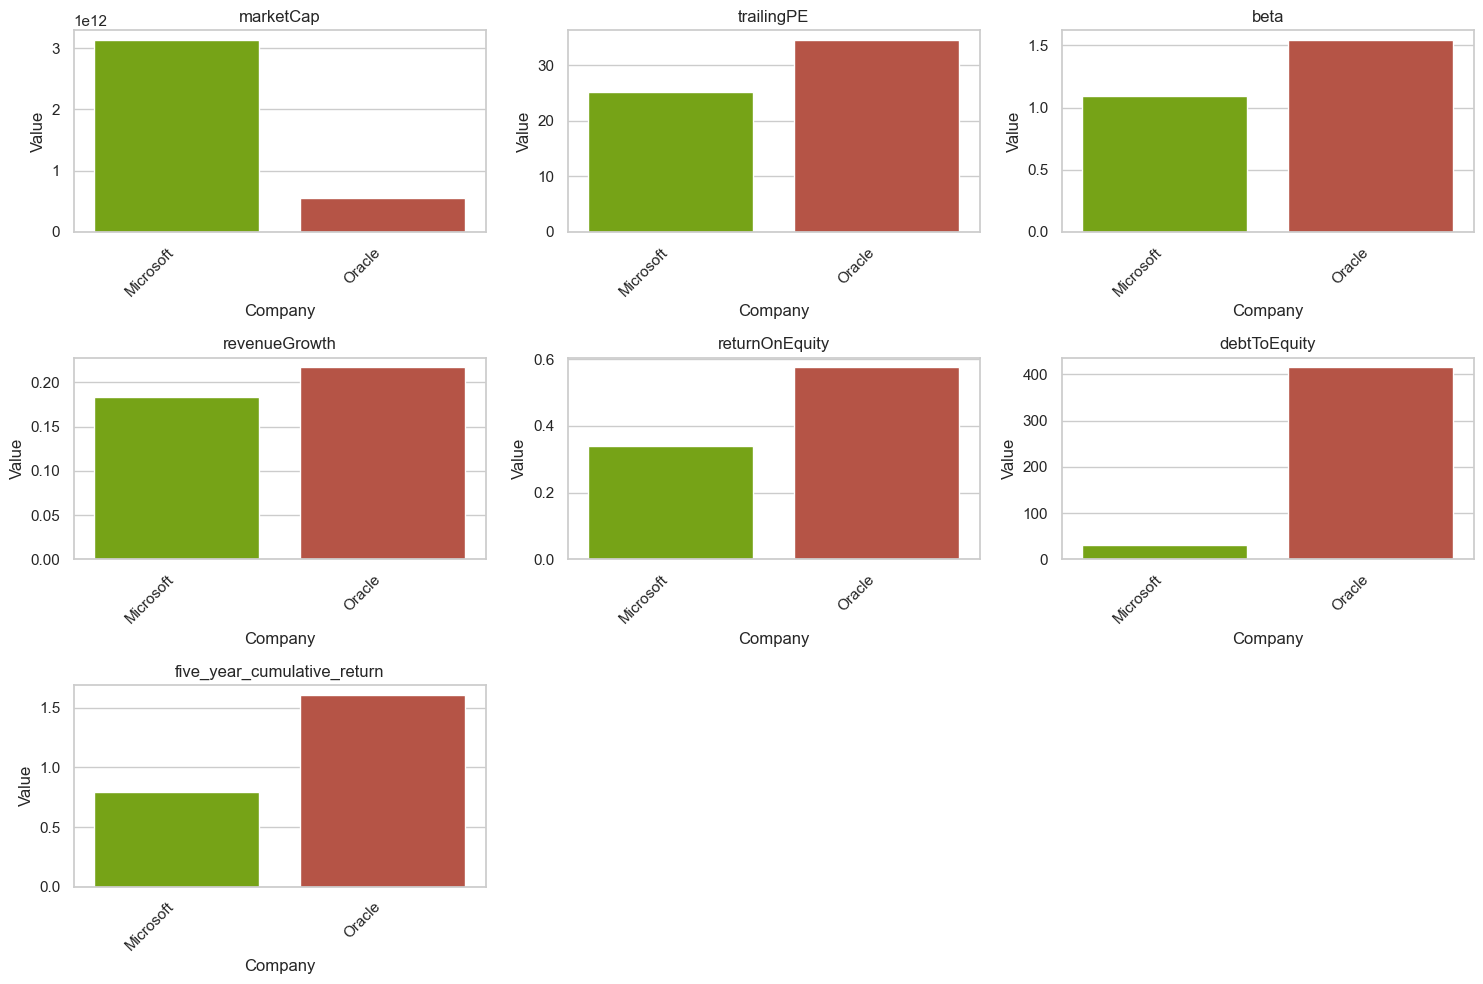

In [10]:
# plt.figure(figsize=(8, 4))
market_long_df = market_df.melt(
    id_vars=["company", "ticker"],
    value_vars=["marketCap", "trailingPE", "beta", "revenueGrowth", "returnOnEquity", "debtToEquity", "five_year_cumulative_return"],
    var_name="metric",
    value_name="value",
)
# sns.barplot(data=market_long_df, x="metric", y="value", hue="company")
# plt.title("Market Context Comparison Across Required Metrics")
# plt.xlabel("Metric")
# plt.ylabel("Value")
# plt.xticks(rotation=45, ha="right")
# plt.tight_layout()
# plt.show()

# 2*3 plot of "marketCap", "trailingPE", "beta", "revenueGrowth", "returnOnEquity", "debtToEquity", "five_year_cumulative_return" for each company
metrics = ["marketCap", "trailingPE", "beta", "revenueGrowth", "returnOnEquity", "debtToEquity", "five_year_cumulative_return"]
plt.figure(figsize=(15, 10))
for i, metric in enumerate(metrics):
    plt.subplot(3, 3, i + 1)
    company_order = market_df["company"].tolist()
    sns.barplot(data=market_df, x="company", y=metric, hue="company", order=company_order, hue_order=company_order, palette=palette_for_companies(company_order), dodge=False, legend=False)
    plt.title(metric)
    plt.xlabel("Company")
    plt.ylabel("Value")
    plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## How to Read the Market Table

Use the table above as your pre-text baseline.

- `marketCap` and `revenueGrowth` speak to scale and expansion.
- `beta` gives a quick volatility signal.
- `returnOnEquity` and `debtToEquity` help frame efficiency versus leverage.
- The 5-year cumulative return helps you compare the narrative evidence to what the market actually rewarded.


# SEC Data Acquisition and Corpus Construction

This section builds the filing manifest and the section-level corpus. The workflow below is local-first:

- it checks the repository cache before attempting SEC downloads,
- it keeps the filing manifest explicit,
- it saves both extraction logs and section-level outputs,
- it extracts Item 7, Item 7A, and Item 8 with multiple end-boundary options, and
- it produces summary tables you can reuse in the report.


In [11]:
SEC_SUBMISSIONS_URL = "https://data.sec.gov/submissions/CIK{cik}.json"
SEC_ARCHIVES_URL = "https://www.sec.gov/Archives/edgar/data/{cik_no_zeros}/{accession}/{primary_document}"


def sec_get(url: str, sleep_seconds: float = 0.2) -> requests.Response:
    response = requests.get(url, headers=HEADERS, timeout=60)
    response.raise_for_status()
    time.sleep(sleep_seconds)
    return response


def records_from_submission_block(block: dict) -> pd.DataFrame:
    return pd.DataFrame(block)


def load_all_submission_frames(cik: str) -> List[pd.DataFrame]:
    cik_10 = str(cik).zfill(10)
    root = sec_get(SEC_SUBMISSIONS_URL.format(cik=cik_10)).json()
    frames = [records_from_submission_block(root["filings"]["recent"])]

    for file_meta in root["filings"].get("files", []):
        file_name = file_meta.get("name")
        if not file_name:
            continue
        older_url = f"https://data.sec.gov/submissions/{file_name}"
        older_json = sec_get(older_url).json()
        frames.append(records_from_submission_block(older_json))

    return frames


def build_10k_manifest(company_cfg: dict) -> pd.DataFrame:
    frames = load_all_submission_frames(company_cfg["cik"])
    filings = pd.concat(frames, ignore_index=True)
    filings = filings.drop_duplicates(subset=["accessionNumber"]).copy()
    filings["filingDate"] = pd.to_datetime(filings["filingDate"])
    filings["year"] = filings["filingDate"].dt.year

    filings = filings[
        (filings["form"] == "10-K")
        & (filings["year"].isin(TARGET_YEARS))
    ].copy()

    filings["company"] = company_cfg["company"]
    filings["ticker"] = company_cfg["ticker"]
    filings["cik"] = str(company_cfg["cik"]).zfill(10)
    filings["accession_nodash"] = filings["accessionNumber"].str.replace("-", "", regex=False)
    filings["cik_no_zeros"] = filings["cik"].str.lstrip("0")
    filings["filing_url"] = filings.apply(
        lambda row: SEC_ARCHIVES_URL.format(
            cik_no_zeros=row["cik_no_zeros"],
            accession=row["accession_nodash"],
            primary_document=row["primaryDocument"],
        ),
        axis=1,
    )

    keep_cols = [
        "company",
        "ticker",
        "cik",
        "form",
        "filingDate",
        "year",
        "accessionNumber",
        "primaryDocument",
        "filing_url",
    ]
    return filings[keep_cols].sort_values(["ticker", "filingDate"]).reset_index(drop=True)


In [12]:
ITEM_END_MAP = {
    "7": ["7A", "8"],
    "7A": ["8", "9"],
    "8": ["9", "9A", "10"],
}


def extract_sec_header_block(raw: str) -> str:
    match = re.search(r"<SEC-HEADER>(.*?)</SEC-HEADER>", raw, flags=re.IGNORECASE | re.DOTALL)
    return match.group(1).strip() if match else ""


def header_value(header_text: str, label: str) -> Optional[str]:
    match = re.search(rf"^\s*{re.escape(label)}:\s*(.+)$", header_text, flags=re.IGNORECASE | re.MULTILINE)
    if match:
        return match.group(1).strip()
    tag_match = re.search(rf"<\s*{re.escape(label)}\s*>\s*([^\n\r<]+)", header_text, flags=re.IGNORECASE)
    return tag_match.group(1).strip() if tag_match else None


def extract_header_section(header_text: str, section_name: str) -> str:
    lines = header_text.splitlines()
    capture = False
    collected = []
    target = section_name.upper()

    for line in lines:
        stripped = line.strip()
        if stripped.upper() == f"{target}:":
            capture = True
            continue
        if capture:
            if stripped and not line.startswith((" ", "\t")) and stripped.endswith(":"):
                break
            collected.append(line)

    return "\n".join(collected).strip()


def parse_sec_header_metadata(raw: str) -> Dict[str, Any]:
    header_text = extract_sec_header_block(raw)
    metadata: Dict[str, Any] = {
        "header_found": bool(header_text),
        "acceptance_datetime": None,
        "public_document_count": None,
        "period_of_report": None,
        "filed_as_of_date": None,
        "date_as_of_change": None,
        "company_conformed_name": None,
        "central_index_key": None,
        "sic_full": None,
        "sic_code_header": None,
        "sic_description": None,
        "organization_name": None,
        "irs_number": None,
        "state_of_incorporation": None,
        "fiscal_year_end_header": None,
        "form_type_header": None,
        "sec_act": None,
        "sec_file_number": None,
        "film_number": None,
        "business_city": None,
        "business_state": None,
        "business_zip": None,
        "business_phone": None,
        "mail_city": None,
        "mail_state": None,
        "mail_zip": None,
        "former_company_name": None,
        "former_name_change_date": None,
    }

    if not header_text:
        return metadata

    metadata.update(
        {
            "acceptance_datetime": header_value(header_text, "ACCEPTANCE-DATETIME"),
            "public_document_count": header_value(header_text, "PUBLIC DOCUMENT COUNT"),
            "period_of_report": header_value(header_text, "CONFORMED PERIOD OF REPORT"),
            "filed_as_of_date": header_value(header_text, "FILED AS OF DATE"),
            "date_as_of_change": header_value(header_text, "DATE AS OF CHANGE"),
            "company_conformed_name": header_value(header_text, "COMPANY CONFORMED NAME"),
            "central_index_key": header_value(header_text, "CENTRAL INDEX KEY"),
            "sic_full": header_value(header_text, "STANDARD INDUSTRIAL CLASSIFICATION"),
            "organization_name": header_value(header_text, "ORGANIZATION NAME"),
            "irs_number": header_value(header_text, "IRS NUMBER"),
            "state_of_incorporation": header_value(header_text, "STATE OF INCORPORATION"),
            "fiscal_year_end_header": header_value(header_text, "FISCAL YEAR END"),
            "form_type_header": header_value(header_text, "FORM TYPE"),
            "sec_act": header_value(header_text, "SEC ACT"),
            "sec_file_number": header_value(header_text, "SEC FILE NUMBER"),
            "film_number": header_value(header_text, "FILM NUMBER"),
            "former_company_name": header_value(header_text, "FORMER CONFORMED NAME"),
            "former_name_change_date": header_value(header_text, "DATE OF NAME CHANGE"),
        }
    )

    sic_full = metadata["sic_full"]
    if sic_full:
        sic_match = re.match(r"(.+?)\s*\[(\d+)\]\s*$", sic_full)
        if sic_match:
            metadata["sic_description"] = sic_match.group(1).strip()
            metadata["sic_code_header"] = sic_match.group(2).strip()
        else:
            metadata["sic_description"] = sic_full.strip()

    business_section = extract_header_section(header_text, "BUSINESS ADDRESS")
    mail_section = extract_header_section(header_text, "MAIL ADDRESS")
    if business_section:
        metadata["business_city"] = header_value(business_section, "CITY")
        metadata["business_state"] = header_value(business_section, "STATE")
        metadata["business_zip"] = header_value(business_section, "ZIP")
        metadata["business_phone"] = header_value(business_section, "BUSINESS PHONE")
    if mail_section:
        metadata["mail_city"] = header_value(mail_section, "CITY")
        metadata["mail_state"] = header_value(mail_section, "STATE")
        metadata["mail_zip"] = header_value(mail_section, "ZIP")

    for date_col in ["period_of_report", "filed_as_of_date", "date_as_of_change", "former_name_change_date"]:
        value = metadata.get(date_col)
        if value:
            metadata[date_col] = pd.to_datetime(value, format="%Y%m%d", errors="coerce")
    if metadata.get("acceptance_datetime"):
        metadata["acceptance_datetime"] = pd.to_datetime(metadata["acceptance_datetime"], format="%Y%m%d%H%M%S", errors="coerce")
    if metadata.get("public_document_count") is not None:
        metadata["public_document_count"] = pd.to_numeric(metadata["public_document_count"], errors="coerce")

    return metadata


def extract_primary_document_markup(raw: str) -> str:
    document_matches = re.findall(r"<DOCUMENT>(.*?)</DOCUMENT>", raw, flags=re.IGNORECASE | re.DOTALL)
    for document_text in document_matches:
        type_match = re.search(r"<TYPE>\s*([^\n\r<]+)", document_text, flags=re.IGNORECASE)
        doc_type = type_match.group(1).strip().upper() if type_match else ""
        if doc_type in {"10-K", "10-K/A", "10K", "FORM 10-K"}:
            text_match = re.search(r"<TEXT>(.*)", document_text, flags=re.IGNORECASE | re.DOTALL)
            return text_match.group(1).strip() if text_match else document_text.strip()
    return raw


def markup_looks_like_xml(markup: str) -> bool:
    stripped = markup.lstrip()
    if stripped.startswith("<?xml"):
        return True
    return bool(re.match(r"^<(xbrl|xml|submission|ownershipDocument)\b", stripped, flags=re.IGNORECASE))


def html_to_text(markup: str) -> str:
    parser = "xml" if markup_looks_like_xml(markup) else "lxml"
    soup = BeautifulSoup(markup, parser)
    for tag in soup(["script", "style"]):
        tag.decompose()
    text = soup.get_text("\n")
    return unescape(text)


def normalize_filing_text(text: str) -> str:
    text = text.replace("\xa0", " ")
    text = re.sub(r"[ \t]+", " ", text)
    text = re.sub(r"\n+", "\n", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def item_start_pattern(item: str) -> str:
    return rf"\bitem\s*{re.escape(item.lower())}\b"


def extract_item_text(full_text: str, item: str, min_chars: int = 500) -> str:
    text = full_text.lower()
    start_matches = list(re.finditer(item_start_pattern(item), text, flags=re.IGNORECASE))
    if not start_matches:
        return ""

    candidate_sections = []
    for start_match in start_matches:
        start_idx = start_match.start()
        end_positions = []
        for next_item in ITEM_END_MAP[item]:
            pattern = item_start_pattern(next_item)
            end_matches = list(re.finditer(pattern, text[start_idx + 1 :], flags=re.IGNORECASE))
            for end_match in end_matches:
                end_positions.append(start_idx + 1 + end_match.start())

        end_positions = [pos for pos in end_positions if pos > start_idx]
        if not end_positions:
            continue

        end_idx = min(end_positions)
        section = full_text[start_idx:end_idx].strip()
        if len(section) >= min_chars:
            candidate_sections.append(section)

    if not candidate_sections:
        return ""

    return max(candidate_sections, key=len)


def find_local_filing_cache(cik: str, accession_nodash: str) -> Optional[Path]:
    cik_no_zeros = str(int(str(cik)))
    patterns = [
        f"*_edgar_data_{cik_no_zeros}_{accession_nodash}.html",
        f"*_edgar_data_{cik_no_zeros}_{accession_nodash}.txt",
    ]

    for base_dir in [*LOCAL_SEC_HTML_DIRS, *LOCAL_SEC_TEXT_DIRS]:
        if not base_dir.exists():
            continue
        for pattern in patterns:
            matches = sorted(base_dir.glob(pattern))
            if matches:
                return matches[0]
    return None


def load_filing_bundle(row: pd.Series) -> Dict[str, Any]:
    local_path = find_local_filing_cache(row["cik"], row["accession_nodash"])
    if local_path is not None:
        raw = local_path.read_text(encoding="utf-8", errors="ignore")
        source = f"local_cache:{local_path.name}"
    else:
        if not ALLOW_SEC_DOWNLOAD:
            return {
                "filing_text": "",
                "source_used": "cache_miss",
                "header_metadata": parse_sec_header_metadata(""),
                "raw_path": None,
            }
        raw = sec_get(row["filing_url"]).text
        source = "sec_download"

    header_metadata = parse_sec_header_metadata(raw)
    primary_markup = extract_primary_document_markup(raw)
    if primary_markup and ("<" in primary_markup and ">" in primary_markup):
        filing_text = normalize_filing_text(html_to_text(primary_markup))
    else:
        filing_text = normalize_filing_text(primary_markup or raw)

    return {
        "filing_text": filing_text,
        "source_used": source,
        "header_metadata": header_metadata,
        "raw_path": str(local_path) if local_path is not None else None,
    }


In [13]:
filings_df = pd.concat([build_10k_manifest(cfg) for cfg in COMPANIES], ignore_index=True)
filings_df["accession_nodash"] = filings_df["accessionNumber"].str.replace("-", "", regex=False)

filing_bundles = {}
manifest_records = []
for filing in filings_df.to_dict(orient="records"):
    bundle = load_filing_bundle(pd.Series(filing))
    filing_bundles[filing["accessionNumber"]] = bundle
    manifest_records.append(
        {
            **filing,
            **bundle["header_metadata"],
            "source_used": bundle["source_used"],
            "raw_path": bundle["raw_path"],
            "filing_char_count": len(bundle["filing_text"]),
        }
    )

filings_df = pd.DataFrame(manifest_records)

print(filings_df.shape)
filings_df.info()
display(filings_df)

coverage_df = filings_df.groupby(["ticker", "year"]).size().rename("filing_count").reset_index()
display(coverage_df)

filings_df.to_csv(ASSIGNMENT_DIR / "filings_manifest.csv", index=False)
coverage_df.to_csv(ASSIGNMENT_DIR / "filings_year_coverage.csv", index=False)


(10, 41)
<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 41 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   company                  10 non-null     str           
 1   ticker                   10 non-null     str           
 2   cik                      10 non-null     str           
 3   form                     10 non-null     str           
 4   filingDate               10 non-null     datetime64[us]
 5   year                     10 non-null     int64         
 6   accessionNumber          10 non-null     str           
 7   primaryDocument          10 non-null     str           
 8   filing_url               10 non-null     str           
 9   accession_nodash         10 non-null     str           
 10  header_found             10 non-null     bool          
 11  acceptance_datetime      0 non-null      object        
 12  public_document_count    0 non-null      

,company,ticker,cik,form,filingDate,year,accessionNumber,primaryDocument,filing_url,accession_nodash,header_found,acceptance_datetime,public_document_count,period_of_report,filed_as_of_date,date_as_of_change,company_conformed_name,central_index_key,sic_full,sic_code_header,sic_description,organization_name,irs_number,state_of_incorporation,fiscal_year_end_header,form_type_header,sec_act,sec_file_number,film_number,business_city,business_state,business_zip,business_phone,mail_city,mail_state,mail_zip,former_company_name,former_name_change_date,source_used,raw_path,filing_char_count
0,Microsoft,MSFT,0000789019,10-K,2020-07-30,2020,0001564590-20-034944,msft-10k_20200630.htm,https://www.sec.gov/Archives/edgar/data/789019/000156459020034944/msft-10k_20200630.htm,000156459020034944,False,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,sec_download,None,371726
1,Microsoft,MSFT,0000789019,10-K,2021-07-29,2021,0001564590-21-039151,msft-10k_20210630.htm,https://www.sec.gov/Archives/edgar/data/789019/000156459021039151/msft-10k_20210630.htm,000156459021039151,False,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,sec_download,None,380132
2,Microsoft,MSFT,0000789019,10-K,2022-07-28,2022,0001564590-22-026876,msft-10k_20220630.htm,https://www.sec.gov/Archives/edgar/data/789019/000156459022026876/msft-10k_20220630.htm,000156459022026876,False,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,sec_download,None,378962
3,Microsoft,MSFT,0000789019,10-K,2023-07-27,2023,0000950170-23-035122,msft-20230630.htm,https://www.sec.gov/Archives/edgar/data/789019/000095017023035122/msft-20230630.htm,000095017023035122,False,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,sec_download,None,373689
4,Microsoft,MSFT,0000789019,10-K,2024-07-30,2024,0000950170-24-087843,msft-20240630.htm,https://www.sec.gov/Archives/edgar/data/789019/000095017024087843/msft-20240630.htm,000095017024087843,False,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,sec_download,None,390416
5,Oracle,ORCL,0001341439,10-K,2020-06-22,2020,0001564590-20-030125,orcl-10k_20200531.htm,https://www.sec.gov/Archives/edgar/data/1341439/000156459020030125/orcl-10k_20200531.htm,000156459020030125,False,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,sec_download,None,488875
6,Oracle,ORCL,0001341439,10-K,2021-06-21,2021,0001564590-21-033616,orcl-10k_20210531.htm,https://www.sec.gov/Archives/edgar/data/1341439/000156459021033616/orcl-10k_20210531.htm,000156459021033616,False,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,sec_download,None,477559
7,Oracle,ORCL,0001341439,10-K,2022-06-21,2022,0001564590-22-023675,orcl-10k_20220531.htm,https://www.sec.gov/Archives/edgar/data/1341439/000156459022023675/orcl-10k_20220531.htm,000156459022023675,False,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,sec_download,None,464229
8,Oracle,ORCL,0001341439,10-K,2023-06-20,2023,0000950170-23-028914,orcl-20230531.htm,https://www.sec.gov/Archives/edgar/data/1341439/000095017023028914/orcl-20230531.htm,000095017023028914,False,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,sec_download,None,469093
9,Oracle,ORCL,0001341439,10-K,2024-06-20,2024,0000950170-24-075605,orcl-20240531.htm,https://www.sec.gov/Archives/edgar/data/1341439/000095017024075605/orcl-20

,ticker,year,filing_count
0,MSFT,2020,1
1,MSFT,2021,1
2,MSFT,2022,1
3,MSFT,2023,1
4,MSFT,2024,1
5,ORCL,2020,1
6,ORCL,2021,1
7,ORCL,2022,1
8,ORCL,2023,1
9,ORCL,2024,1


(30, 22)
<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   company                 30 non-null     str           
 1   ticker                  30 non-null     str           
 2   naics_code              30 non-null     str           
 3   year                    30 non-null     int64         
 4   filing_date             30 non-null     datetime64[us]
 5   accession_number        30 non-null     str           
 6   filing_url              30 non-null     str           
 7   source_used             30 non-null     str           
 8   header_found            30 non-null     bool          
 9   period_of_report        0 non-null      object        
 10  acceptance_datetime     0 non-null      object        
 11  public_document_count   0 non-null      object        
 12  sic_code_header         0 non-null      object        

,company,ticker,naics_code,year,filing_date,accession_number,filing_url,source_used,header_found,period_of_report,acceptance_datetime,public_document_count,sic_code_header,sic_description,state_of_incorporation,fiscal_year_end_header,sec_file_number,business_state,item,raw_text,char_count,section_found
0,Microsoft,MSFT,5112,2020,2020-07-30,0001564590-20-034944,https://www.sec.gov/Archives/edgar/data/789019/000156459020034944/msft-10k_20200630.htm,sec_download,False,None,None,None,None,None,None,None,None,None,7,Item 7 Productivity and Business Processes and Intelligent Cloud Metrics related to our Productivity and Business Processes and Intelligent Cloud segments assess the health of our core businesses ...,26075,True
1,Microsoft,MSFT,5112,2020,2020-07-30,0001564590-20-034944,https://www.sec.gov/Archives/edgar/data/789019/000156459020034944/msft-10k_20200630.htm,sec_download,False,None,None,None,None,None,None,None,None,None,7A,"Item 7A of this Form 10-K). Readers are cautioned not to place undue reliance on forward-looking statements, which speak only as of the date they are made. We undertake no obligation to update or ...",18327,True
2,Microsoft,MSFT,5112,2020,2020-07-30,0001564590-20-034944,https://www.sec.gov/Archives/edgar/data/789019/000156459020034944/msft-10k_20200630.htm,sec_download,False,None,None,None,None,None,None,None,None,None,8,Item 8 of this Form 10-K). Our reportable segments are described below. Productivity and Business Processes Our Productivity and Business Processes segment consists of products and services in our...,287971,True
3,Microsoft,MSFT,5112,2021,2021-07-29,0001564590-21-039151,https://www.sec.gov/Archives/edgar/data/789019/000156459021039151/msft-10k_20210630.htm,sec_download,False,None,None,None,None,None,None,None,None,None,7,Item 7 Operating income increased $17.0 billion or 32% driven by growth across each of our segments and the change in estimated useful lives of our server and network equipment. Current year net i...,19007,True
4,Microsoft,MSFT,5112,2021,2021-07-29,0001564590-21-039151,https://www.sec.gov/Archives/edgar/data/789019/000156459021039151/msft-10k_20210630.htm,sec_download,False,None,None,None,None,None,None,None,None,None,7A,"Item 7A of this Form 10-K). Readers are cautioned not to place undue reliance on forward-looking statements, which speak only as of the date they are made. We undertake no obligation to update or ...",32373,True


,ticker,year,item,section_found
0,MSFT,2020,7,1
1,MSFT,2020,7A,1
2,MSFT,2020,8,1
3,MSFT,2021,7,1
4,MSFT,2021,7A,1
5,MSFT,2021,8,1
6,MSFT,2022,7,1
7,MSFT,2022,7A,1
8,MSFT,2022,8,1
9,MSFT,2023,7,1


,ticker,item,count,mean,median,min,max
0,MSFT,7,5,21715.4,20352.0,19007,26075
1,MSFT,7A,5,27410.4,28675.0,18327,34529
2,MSFT,8,5,285228.2,282034.0,279266,297084
3,ORCL,7,5,223510.6,223758.0,219687,228532
4,ORCL,7A,5,6978.6,5483.0,5286,10808
5,ORCL,8,5,0.0,0.0,0,0


,ticker,year,filingDate,source_used,filing_char_count,header_found,acceptance_datetime,period_of_report,public_document_count,state_of_incorporation,sec_file_number
0,MSFT,2020,2020-07-30,sec_download,371726,False,None,None,None,None,None
1,MSFT,2021,2021-07-29,sec_download,380132,False,None,None,None,None,None
2,MSFT,2022,2022-07-28,sec_download,378962,False,None,None,None,None,None
3,MSFT,2023,2023-07-27,sec_download,373689,False,None,None,None,None,None
4,MSFT,2024,2024-07-30,sec_download,390416,False,None,None,None,None,None
5,ORCL,2020,2020-06-22,sec_download,488875,False,None,None,None,None,None
6,ORCL,2021,2021-06-21,sec_download,477559,False,None,None,None,None,None
7,ORCL,2022,2022-06-21,sec_download,464229,False,None,None,None,None,None
8,ORCL,2023,2023-06-20,sec_download,469093,False,None,None,None,None,None
9,ORCL,2024,2024-06-20,sec_download,457391,False,None,None,None,None,None


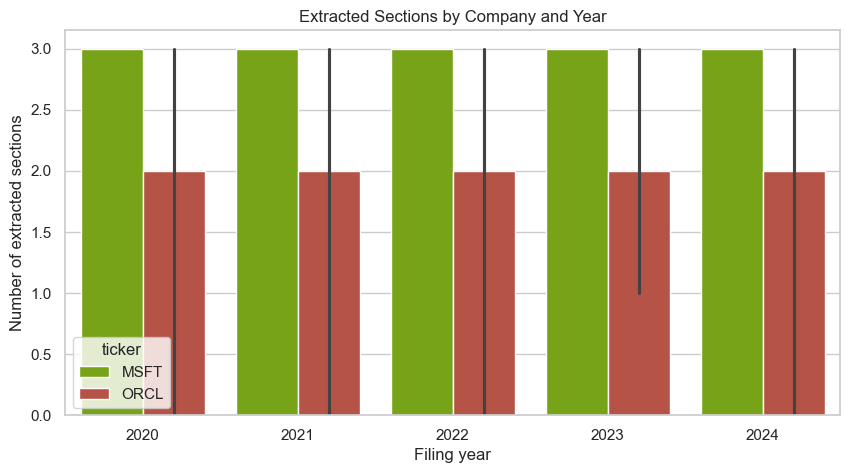

In [14]:
corpus_records = []
extraction_log = []

for filing in filings_df.to_dict(orient="records"):
    bundle = filing_bundles.get(filing["accessionNumber"])
    if bundle is None:
        bundle = load_filing_bundle(pd.Series(filing))
        filing_bundles[filing["accessionNumber"]] = bundle

    filing_text = bundle["filing_text"]
    source_used = bundle["source_used"]
    header_metadata = bundle["header_metadata"]

    extraction_log.append(
        {
            "ticker": filing["ticker"],
            "year": filing["year"],
            "filingDate": filing["filingDate"],
            "source_used": source_used,
            "filing_char_count": len(filing_text),
            "header_found": header_metadata["header_found"],
            "acceptance_datetime": header_metadata["acceptance_datetime"],
            "period_of_report": header_metadata["period_of_report"],
            "public_document_count": header_metadata["public_document_count"],
            "state_of_incorporation": header_metadata["state_of_incorporation"],
            "sec_file_number": header_metadata["sec_file_number"],
        }
    )

    for item in TARGET_ITEMS:
        section_text = extract_item_text(filing_text, item=item)
        corpus_records.append(
            {
                "company": filing["company"],
                "ticker": filing["ticker"],
                "naics_code": NAICS_CODE,
                "year": filing["year"],
                "filing_date": filing["filingDate"],
                "accession_number": filing["accessionNumber"],
                "filing_url": filing["filing_url"],
                "source_used": source_used,
                "header_found": header_metadata["header_found"],
                "period_of_report": header_metadata["period_of_report"],
                "acceptance_datetime": header_metadata["acceptance_datetime"],
                "public_document_count": header_metadata["public_document_count"],
                "sic_code_header": header_metadata["sic_code_header"],
                "sic_description": header_metadata["sic_description"],
                "state_of_incorporation": header_metadata["state_of_incorporation"],
                "fiscal_year_end_header": header_metadata["fiscal_year_end_header"],
                "sec_file_number": header_metadata["sec_file_number"],
                "business_state": header_metadata["business_state"],
                "item": item,
                "raw_text": section_text,
                "char_count": len(section_text),
                "section_found": bool(section_text),
            }
        )

corpus_df = pd.DataFrame(corpus_records)
extraction_df = pd.DataFrame(extraction_log)

coverage_by_item_df = (
    corpus_df.groupby(["ticker", "year", "item"])["section_found"]
    .sum()
    .reset_index()
)
char_summary_df = (
    corpus_df.groupby(["ticker", "item"])["char_count"]
    .agg(["count", "mean", "median", "min", "max"])
    .reset_index()
)

print(corpus_df.shape)
corpus_df.info()
display(corpus_df.head())
display(coverage_by_item_df)
display(char_summary_df)
display(extraction_df)

plt.figure(figsize=(10, 5))
ticker_order = [cfg["ticker"] for cfg in COMPANIES if cfg["ticker"] in coverage_by_item_df["ticker"].unique()]
sns.barplot(data=coverage_by_item_df, x="year", y="section_found", hue="ticker", hue_order=ticker_order, palette=palette_for_tickers(ticker_order), estimator=sum)
plt.title("Extracted Sections by Company and Year")
plt.ylabel("Number of extracted sections")
plt.xlabel("Filing year")
plt.show()

corpus_df.to_csv(ASSIGNMENT_DIR / "corpus.csv", index=False)
extraction_df.to_csv(ASSIGNMENT_DIR / "extraction_log.csv", index=False)
coverage_by_item_df.to_csv(ASSIGNMENT_DIR / "corpus_section_coverage.csv", index=False)
char_summary_df.to_csv(ASSIGNMENT_DIR / "corpus_char_summary.csv", index=False)



## Q1 Review: Corpus Construction Quality

Before students interpret model results, they should confirm the corpus is complete and analytically usable.

Key review questions:

- Did both companies produce all expected sections across 2020-2024?
- Are there major section-length imbalances that could distort the comparison?
- Do a few sample extracted rows look like real Item 7, Item 7A, and Item 8 content rather than extraction noise?


,company,item,sections_found,avg_chars,median_chars
0,Microsoft,7,5,21715.4,20352.0
1,Microsoft,7A,5,27410.4,28675.0
2,Microsoft,8,5,285228.2,282034.0
3,Oracle,7,5,223510.6,223758.0
4,Oracle,7A,5,6978.6,5483.0
5,Oracle,8,0,0.0,0.0


ticker     MSFT  ORCL
year item            
2020 7      1.0   1.0
     7A     1.0   1.0
     8      1.0   0.0
2021 7      1.0   1.0
     7A     1.0   1.0
     8      1.0   0.0
2022 7      1.0   1.0
     7A     1.0   1.0
     8      1.0   0.0
2023 7      1.0   1.0
     7A     1.0   1.0
     8      1.0   0.0
2024 7      1.0   1.0
     7A     1.0   1.0
     8      1.0   0.0

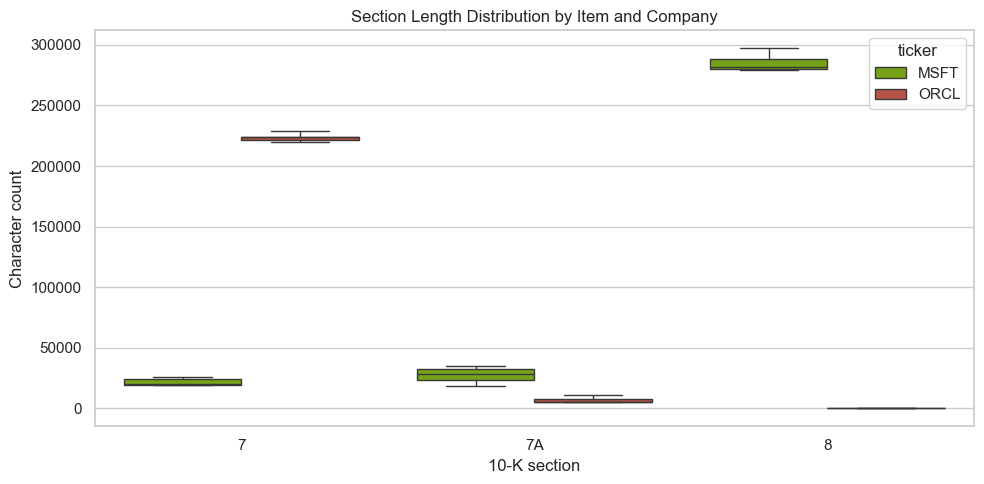

,company,year,item,raw_text_preview
0,Microsoft,2020,7,Item 7 Productivity and Business Processes and Intelligent Cloud Metrics related to our Productivity and Business Processes and Intelligent Cloud segments assess the health of our core businesses ...
1,Microsoft,2020,7A,"Item 7A of this Form 10-K). Readers are cautioned not to place undue reliance on forward-looking statements, which speak only as of the date they are made. We undertake no obligation to update or ..."
2,Microsoft,2020,8,Item 8 of this Form 10-K). Our reportable segments are described below. Productivity and Business Processes Our Productivity and Business Processes segment consists of products and services in our...
3,Microsoft,2021,7,Item 7 Operating income increased $17.0 billion or 32% driven by growth across each of our segments and the change in estimated useful lives of our server and network equipment. Current year net i...
4,Microsoft,2021,7A,"Item 7A of this Form 10-K). Readers are cautioned not to place undue reliance on forward-looking statements, which speak only as of the date they are made. We undertake no obligation to update or ..."
5,Microsoft,2021,8,Item 8 of this Form 10-K). Our reportable segments are described below. Productivity and Business Processes Our Productivity and Business Processes segment consists of products and services in our...


In [15]:

corpus_review_df = (
    corpus_df.groupby(["company", "item"])
    .agg(
        sections_found=("section_found", "sum"),
        avg_chars=("char_count", "mean"),
        median_chars=("char_count", "median"),
    )
    .reset_index()
)
display(corpus_review_df)

section_pivot_df = coverage_by_item_df.pivot_table(
    index=["year", "item"],
    columns="ticker",
    values="section_found",
    fill_value=0,
)
display(section_pivot_df)

plt.figure(figsize=(10, 5))
ticker_order = [cfg["ticker"] for cfg in COMPANIES if cfg["ticker"] in corpus_df["ticker"].unique()]
sns.boxplot(data=corpus_df, x="item", y="char_count", hue="ticker", hue_order=ticker_order, palette=palette_for_tickers(ticker_order))
plt.title("Section Length Distribution by Item and Company")
plt.xlabel("10-K section")
plt.ylabel("Character count")
plt.tight_layout()
plt.show()

sample_sections_df = corpus_df.loc[
    corpus_df["section_found"],
    ["company", "year", "item", "raw_text"],
].copy()
sample_sections_df["raw_text_preview"] = sample_sections_df["raw_text"].str.slice(0, 400)
display(sample_sections_df[["company", "year", "item", "raw_text_preview"]].head(6))

corpus_review_df.to_csv(ASSIGNMENT_DIR / "corpus_review_table.csv", index=False)
section_pivot_df.reset_index().to_csv(ASSIGNMENT_DIR / "corpus_section_presence_pivot.csv", index=False)


## How to Read the Extraction Output

Three quick checks matter here:

- Coverage: did both firms produce Item 7, Item 7A, and Item 8 for all target years?
- Scale: are section lengths in the same rough range, or is one firm much more verbose?
- Source: did the notebook use local cache files or live SEC downloads?

If any section is missing repeatedly, mention that as a limitation in the report.


# Sentence Chunking

Chunking makes the filing sections easier to compare and classify. The assignment asks for roughly 3-5 sentences per chunk with overlap; the helper below uses 4-sentence windows with 1-sentence overlap.

Required evidence:

- show the resulting `chunks_df`,
- report chunk counts by company and item,
- visualize chunk length with a histogram, and
- save a summary table for later write-up use.


(4525, 9)
<class 'pandas.DataFrame'>
RangeIndex: 4525 entries, 0 to 4524
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   chunk_id      4525 non-null   str  
 1   company       4525 non-null   str  
 2   ticker        4525 non-null   str  
 3   naics_code    4525 non-null   str  
 4   year          4525 non-null   int64
 5   item          4525 non-null   str  
 6   chunk_number  4525 non-null   int64
 7   chunk_text    4525 non-null   str  
 8   char_count    4525 non-null   int64
dtypes: int64(3), str(6)
memory usage: 4.1 MB


,chunk_id,company,ticker,naics_code,year,item,chunk_number,chunk_text,char_count
0,MSFT_2020_7_1,Microsoft,MSFT,5112,2020,7,1,Item 7 Productivity and Business Processes and Intelligent Cloud Metrics related to our Productivity and Business Processes and Intelligent Cloud segments assess the health of our core businesses ...,2225
1,MSFT_2020_7_2,Microsoft,MSFT,5112,2020,7,2,These metrics provide strategic product insights which allow us to assess the performance across our commercial and consumer businesses. As we have diversity of target audiences and sales motions ...,2229
2,MSFT_2020_7_3,Microsoft,MSFT,5112,2020,7,3,Refer to the Non-GAAP Financial Measures section below for a reconciliation of our financial results reported in accordance with GAAP to non-GAAP financial results. Fiscal Year 2020 Compared with ...,478
3,MSFT_2020_7_4,Microsoft,MSFT,5112,2020,7,4,"Productivity and Business Processes revenue increased, driven by Office Commercial and LinkedIn. More Personal Computing revenue increased, driven by Windows and Surface. Gross margin increased $1...",351
4,MSFT_2020_7_5,Microsoft,MSFT,5112,2020,7,5,"Gross margin percentage increased, driven by sales mix shift to higher margin businesses. Commercial cloud gross margin percentage increased 4 points to 67%, primarily driven by improvement in Azu...",410


,ticker,item,chunk_count,mean_chars,median_chars
0,MSFT,7,204,701.848039,602.5
1,MSFT,7A,277,661.501805,647.0
2,MSFT,8,2463,780.432806,670.0
3,ORCL,7,1524,972.509186,876.0
4,ORCL,7A,57,784.245614,734.0


,count,mean,std,min,25%,50%,75%,max
ticker,,,,,,,,
MSFT,2944.0,763.797215,505.532024,124.0,542.0,664.0,823.25,5920.0
ORCL,1581.0,965.721695,464.204585,233.0,692.0,865.0,1100.00,6005.0


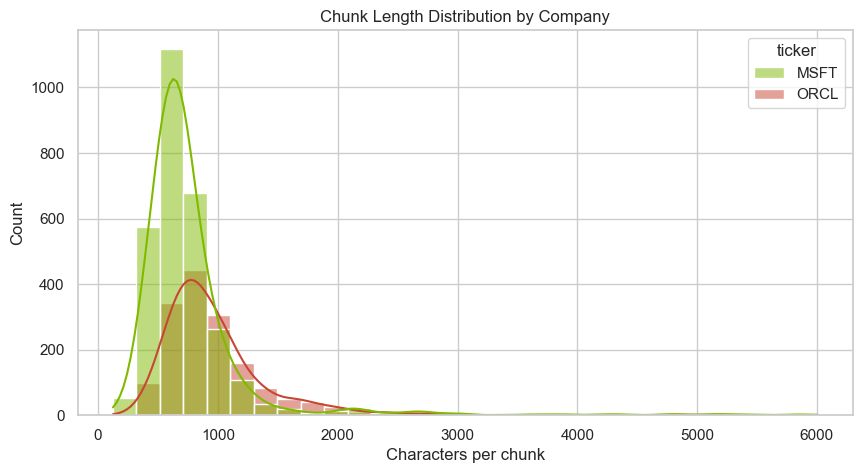

In [16]:
valid_corpus_df = corpus_df[corpus_df["section_found"]].copy()


def chunk_text(text: str, chunk_size: int = 4, overlap: int = 1) -> List[str]:
    sentences = [s.strip() for s in sent_tokenize(text) if s.strip()]
    if not sentences:
        return []

    step = max(1, chunk_size - overlap)
    chunks = []
    for start in range(0, len(sentences), step):
        chunk = " ".join(sentences[start : start + chunk_size]).strip()
        if len(chunk) >= 100:
            chunks.append(chunk)
        if start + chunk_size >= len(sentences):
            break
    return chunks


chunk_records = []
for row in valid_corpus_df.itertuples(index=False):
    chunks = chunk_text(row.raw_text, chunk_size=CHUNK_SIZE, overlap=CHUNK_OVERLAP)
    for chunk_number, chunk in enumerate(chunks, start=1):
        chunk_records.append(
            {
                "chunk_id": f"{row.ticker}_{row.year}_{row.item}_{chunk_number}",
                "company": row.company,
                "ticker": row.ticker,
                "naics_code": row.naics_code,
                "year": row.year,
                "item": row.item,
                "chunk_number": chunk_number,
                "chunk_text": chunk,
                "char_count": len(chunk),
            }
        )

chunks_df = pd.DataFrame(chunk_records)
chunk_summary_df = chunks_df.groupby(["ticker", "item"]).agg(
    chunk_count=("chunk_id", "count"),
    mean_chars=("char_count", "mean"),
    median_chars=("char_count", "median"),
).reset_index()

print(chunks_df.shape)
chunks_df.info()
display(chunks_df.head())
display(chunk_summary_df)
display(chunks_df.groupby("ticker")["char_count"].describe())

plt.figure(figsize=(10, 5))
ticker_order = [cfg["ticker"] for cfg in COMPANIES if cfg["ticker"] in chunks_df["ticker"].unique()]
sns.histplot(data=chunks_df, x="char_count", hue="ticker", hue_order=ticker_order, palette=palette_for_tickers(ticker_order), bins=30, kde=True)
plt.title("Chunk Length Distribution by Company")
plt.xlabel("Characters per chunk")
plt.show()

chunks_df.to_csv(ASSIGNMENT_DIR / "chunks.csv", index=False)
chunk_summary_df.to_csv(ASSIGNMENT_DIR / "chunk_summary.csv", index=False)


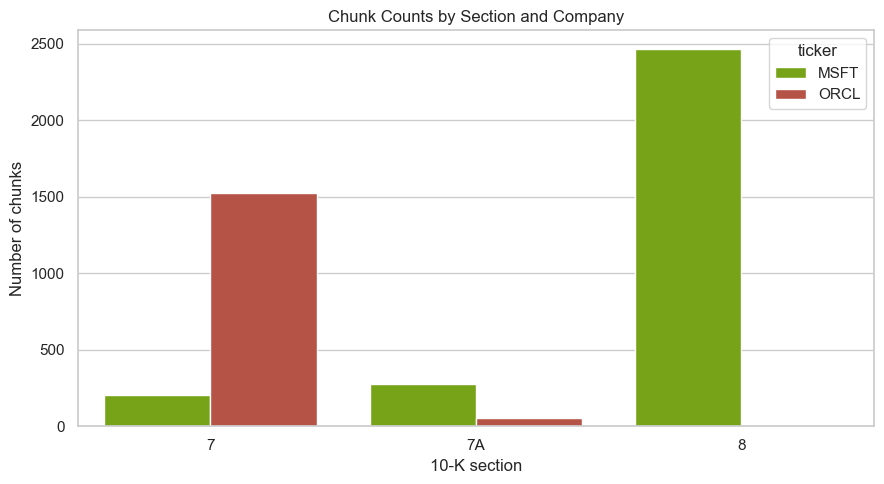

In [17]:

plt.figure(figsize=(9, 5))
ticker_order = [cfg["ticker"] for cfg in COMPANIES if cfg["ticker"] in chunk_summary_df["ticker"].unique()]
sns.barplot(data=chunk_summary_df, x="item", y="chunk_count", hue="ticker", hue_order=ticker_order, palette=palette_for_tickers(ticker_order))
plt.title("Chunk Counts by Section and Company")
plt.xlabel("10-K section")
plt.ylabel("Number of chunks")
plt.tight_layout()
plt.show()


# TF-IDF Feature Engineering

This section creates the vocabulary and the chunk-level TF-IDF matrix, then compares the two firms' most distinctive terms.

Required evidence:

- save `vocab.json` and `tfidf_matrix.csv`,
- show top terms for both companies,
- save a compact term-summary table, and
- explain which terms look financially or strategically meaningful.


(4525, 5002)


,chunk_id,00,ticker,000,008,015,032,04,052,058,088,0ppt,10,10 billion,10 decrease,10 discussion,10 driven,10 years,100,100 basis,101,102,103,104,105,106,107,109,109 433,10b5,11,11 billion,11 debt,11 driven,110,111,116,117,118,119,12,12 billion,12 driven,12 income,12 months,120,122,123,125,125 843,...,women,work,work environment,workers,workforce,working,working capital,workloads,workloads oracle,world,world popular,worldwide,write,written,www,www microsoft,www oracle,www sec,xbox,xbox cloud,xbox consoles,xbox content,xbox game,xbox hardware,year,year 2016,year 2018,year 2019,year 2020,year 2021,year 2022,year 2023,year 2024,year agreements,year ended,year ending,year period,year premises,years,years 1996,years 2004,years 2020,years 2021,years 2022,years 2023,years 2024,years years,yen,zenimax,zenimax media
0,MSFT_2020_7_1,0.0,MSFT,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,MSFT_2020_7_2,0.0,MSFT,0.0,0.0,0.044914,0.0,0.0,0.0,0.044598,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.044296,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.042035,0.047633,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.095176,0.0,0.0,0.079986,0.0,0.0,0.018930,0.0,0.0,0.037223,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.024762,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,MSFT_2020_7_3,0.0,MSFT,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.107394,0.0,0.0,0.105586,0.103527,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,MSFT_2020_7_4,0.0,MSFT,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,MSFT_2020_7_5,0.0,MSFT,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.074885,0.125395,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,term,mean_tfidf
0,services,0.032914
1,revenue,0.031122
2,products,0.026273
3,tax,0.022488
4,cloud,0.022101
5,income,0.020541
6,microsoft,0.020495
7,billion,0.019939
8,business,0.018994
9,software,0.018250


,term,mean_tfidf
0,oracle,0.059791
1,cloud,0.045266
2,license,0.035727
3,revenues,0.034284
4,hardware,0.033892
5,services,0.032797
6,business,0.031260
7,offerings,0.029582
8,products,0.026210
9,fiscal,0.025421


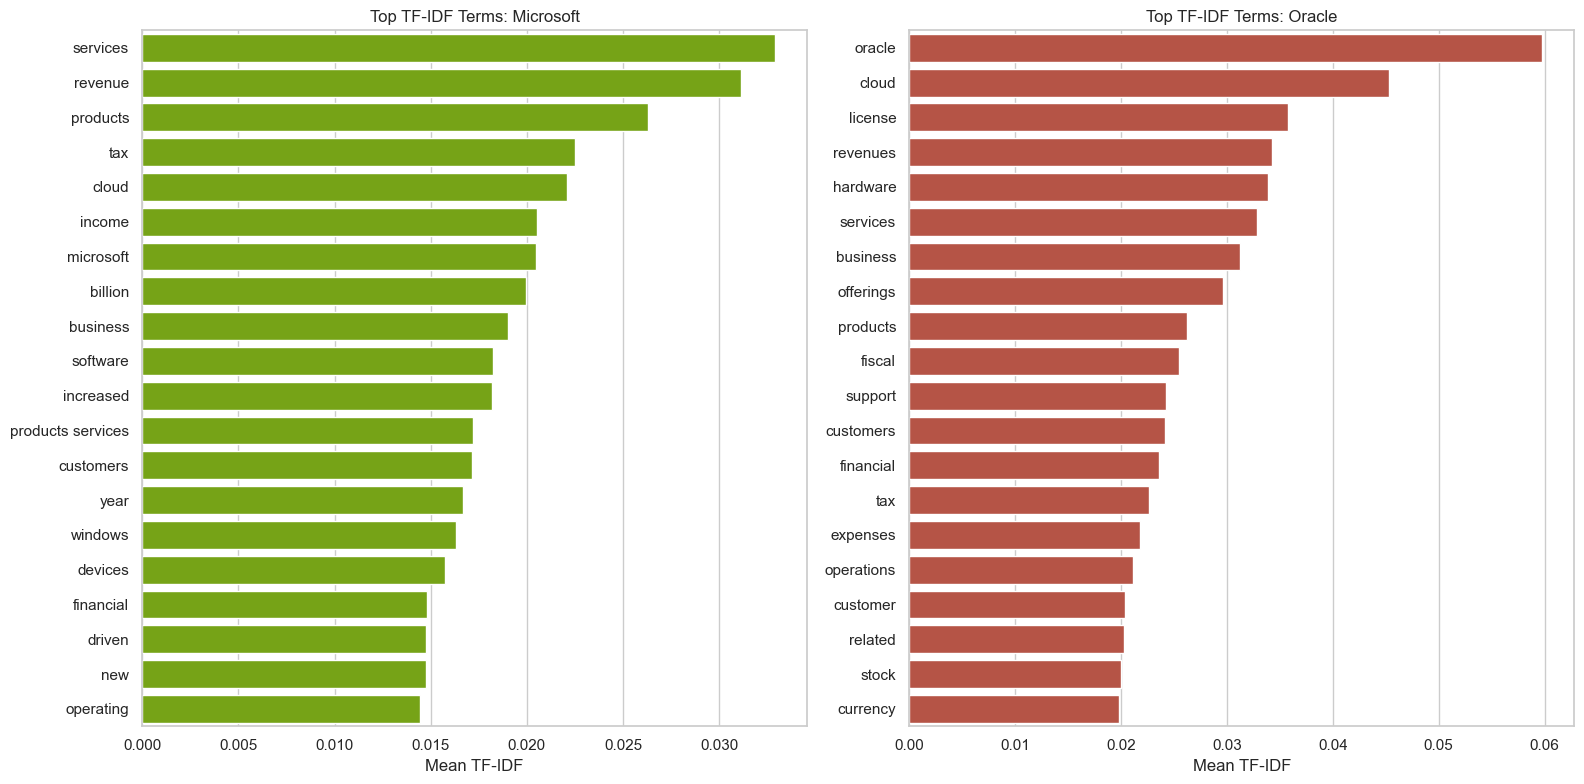

In [18]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
)

X = vectorizer.fit_transform(chunks_df["chunk_text"])
vocab = vectorizer.get_feature_names_out().tolist()

tfidf_df = pd.DataFrame(X.toarray(), columns=vocab)
tfidf_df.insert(0, "chunk_id", chunks_df["chunk_id"].values)
# tfidf_df.insert(1, "company", chunks_df["company"].values)
tfidf_df.insert(2, "ticker", chunks_df["ticker"].values)
# tfidf_df.insert(3, "year", chunks_df["year"].values)
# tfidf_df.insert(4, "item", chunks_df["item"].values)

with open(ASSIGNMENT_DIR / "vocab.json", "w", encoding="utf-8") as f:
    json.dump(vocab, f, indent=2)

tfidf_df.to_csv(ASSIGNMENT_DIR / "tfidf_matrix.csv", index=False)

term_means = (
    pd.DataFrame(X.toarray(), columns=vocab)
    .assign(company=chunks_df["company"].values)
    .groupby("company")
    .mean()
)

company_a, company_b = [cfg["company"] for cfg in COMPANIES]


def top_terms_for_company(company_name: str, n: int = 20) -> pd.DataFrame:
    top = term_means.loc[company_name].sort_values(ascending=False).head(n)
    return top.rename_axis("term").reset_index(name="mean_tfidf")


top_a = top_terms_for_company(company_a)
top_b = top_terms_for_company(company_b)
top_terms_df = pd.concat(
    [top_a.assign(company=company_a), top_b.assign(company=company_b)],
    ignore_index=True,
)

print(tfidf_df.shape)
display(tfidf_df.head())
display(top_a)
display(top_b)

fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharex=False)
sns.barplot(data=top_a, x="mean_tfidf", y="term", ax=axes[0], color=COMPANY_COLORS[company_a])
axes[0].set_title(f"Top TF-IDF Terms: {company_a}")
axes[0].set_xlabel("Mean TF-IDF")
axes[0].set_ylabel("")

sns.barplot(data=top_b, x="mean_tfidf", y="term", ax=axes[1], color=COMPANY_COLORS[company_b])
axes[1].set_title(f"Top TF-IDF Terms: {company_b}")
axes[1].set_xlabel("Mean TF-IDF")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

top_terms_df.to_csv(ASSIGNMENT_DIR / "top_terms_by_company.csv", index=False)


(10, 3)


,year,item,cosine_similarity
0,2020,7,0.256552
1,2020,7A,0.049459
2,2021,7,0.294891
3,2021,7A,0.050304
4,2022,7,0.321542
5,2022,7A,0.047095
6,2023,7,0.336972
7,2023,7A,0.062154
8,2024,7,0.302282
9,2024,7A,0.045624


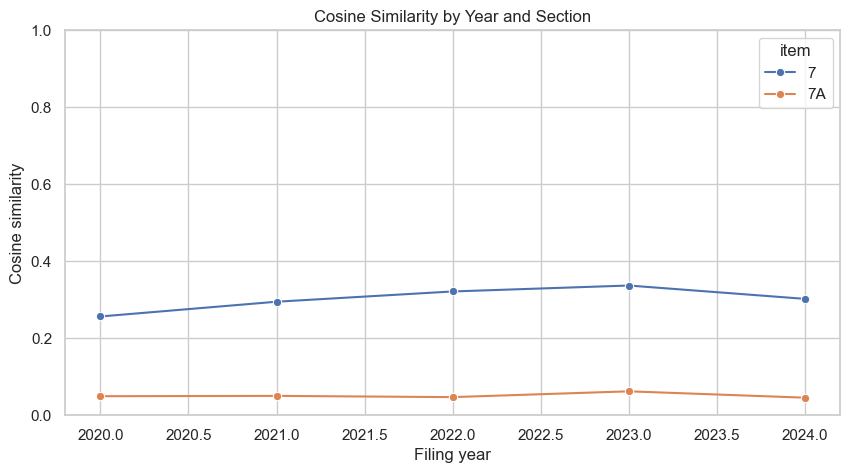

In [19]:
sim_records = []
X_dense = pd.DataFrame(X.toarray(), columns=vocab, index=chunks_df.index)

for year in sorted(chunks_df["year"].unique()):
    for item in TARGET_ITEMS:
        subset = chunks_df[(chunks_df["year"] == year) & (chunks_df["item"] == item)]
        if subset["company"].nunique() < 2:
            continue

        idx_a = subset[subset["company"] == company_a].index
        idx_b = subset[subset["company"] == company_b].index
        if len(idx_a) == 0 or len(idx_b) == 0:
            continue

        vec_a = X_dense.loc[idx_a].mean(axis=0).to_frame().T
        vec_b = X_dense.loc[idx_b].mean(axis=0).to_frame().T
        sim = cosine_similarity(vec_a, vec_b)[0][0]

        sim_records.append(
            {
                "year": year,
                "item": item,
                "cosine_similarity": sim,
            }
        )

sim_df = pd.DataFrame(sim_records)
print(sim_df.shape)
display(sim_df)

plt.figure(figsize=(10, 5))
sns.lineplot(data=sim_df, x="year", y="cosine_similarity", hue="item", marker="o")
plt.title("Cosine Similarity by Year and Section")
plt.xlabel("Filing year")
plt.ylabel("Cosine similarity")
plt.ylim(0, 1)
plt.show()

sim_df.to_csv(ASSIGNMENT_DIR / "cosine_similarity_by_year_item.csv", index=False)


item,7,7A
year,,
2020,0.256552,0.049459
2021,0.294891,0.050304
2022,0.321542,0.047095
2023,0.336972,0.062154
2024,0.302282,0.045624


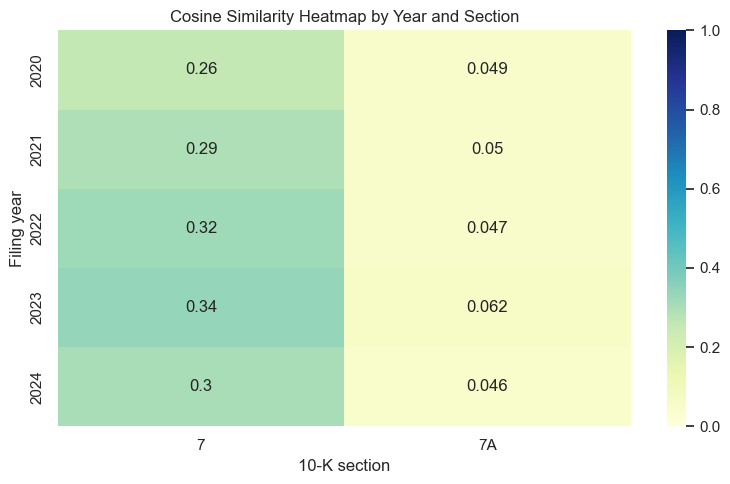

In [20]:

similarity_pivot_df = sim_df.pivot(index="year", columns="item", values="cosine_similarity")
display(similarity_pivot_df)

plt.figure(figsize=(8, 5))
sns.heatmap(similarity_pivot_df, annot=True, cmap="YlGnBu", vmin=0, vmax=1)
plt.title("Cosine Similarity Heatmap by Year and Section")
plt.xlabel("10-K section")
plt.ylabel("Filing year")
plt.tight_layout()
plt.show()

similarity_pivot_df.reset_index().to_csv(ASSIGNMENT_DIR / "cosine_similarity_heatmap_table.csv", index=False)


## How to Read the TF-IDF Outputs

Use the TF-IDF section to answer two kinds of questions.

- Distinctiveness: which words or phrases most strongly separate the companies?
- Stability: do the two firms become more or less similar over time within the same section?

The top-term chart is especially useful for Q3 because it connects narrative emphasis to business interpretation.


# PyTorch Bag-of-Words Classifier

The assignment asks for a simple neural model, not a large language model. A one-layer bag-of-words classifier is enough for this comparison and keeps the logic easy to explain.

Required evidence:

- classifier accuracy,
- a confusion matrix,
- a cosine-similarity baseline,
- a small misclassification table,
- saved model weights, and
- a compact results table saved to disk.


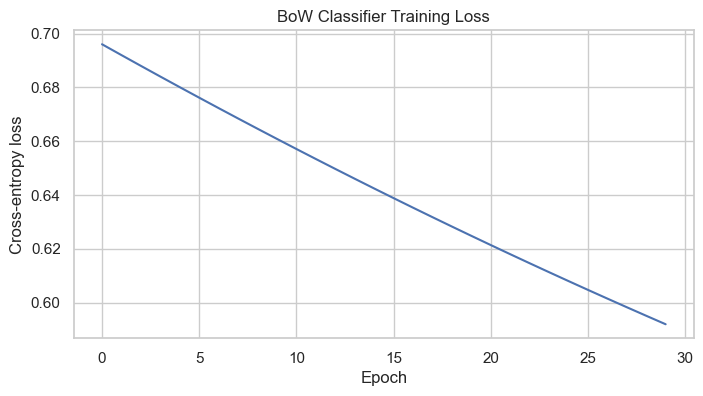

BoW accuracy: 0.8309
              precision    recall  f1-score   support

      Oracle       1.00      0.52      0.68       316
   Microsoft       0.79      1.00      0.89       589

    accuracy                           0.83       905
   macro avg       0.90      0.76      0.78       905
weighted avg       0.87      0.83      0.81       905

Cosine baseline accuracy: 0.9978


,method,accuracy
0,Cosine Similarity Baseline,0.997790
1,PyTorch BoW Classifier,0.830939


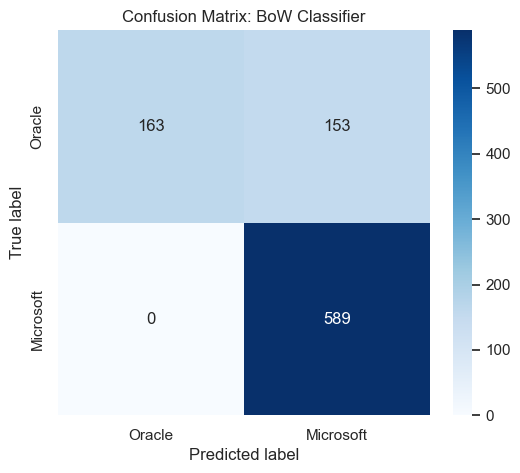

,chunk_id,item,year,chunk_text,true_company,predicted_company
4091,ORCL_2023_7_188,7,2023,"A significant portion of our critical business operations are concentrated in a few geographic areas, some of which include emerging market international locations that may be less stable relative...",Oracle,Microsoft
3995,ORCL_2023_7_92,7,2023,"In connection with these investments, we entered, and expect to continue to enter, into long-term operating lease commitments with third party data center providers that generally require us to pa...",Oracle,Microsoft
4267,ORCL_2024_7_51,7,2024,"Research and Development We develop the substantial majority of our products and services offerings internally utilizing the skills and diversity of a global workforce. In addition, we have extend...",Oracle,Microsoft
3508,ORCL_2021_7_238,7,2021,We calculate our current and deferred tax provision based on estimates and assumptions that could differ from the actual results reflected in income tax returns filed during the subsequent year. A...,Oracle,Microsoft
3963,ORCL_2023_7_60,7,2023,Examples of recognition received include being named one of the World’s Top Female-Friendly Companies and one of America’s Best Employers For Women by Forbes in 2022 and one of America’s Best Empl...,Oracle,Microsoft


In [21]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
LABEL_MAP = {company_b: 0, company_a: 1}


def make_labels(frame: pd.DataFrame) -> np.ndarray:
    return frame["company"].map(LABEL_MAP).to_numpy()


class BoWClassifier(nn.Module):
    def __init__(self, vocab_size: int, num_classes: int = 2):
        super().__init__()
        self.linear = nn.Linear(vocab_size, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear(x)


def split_sparse_with_index(feature_matrix, labels):
    idx = np.arange(len(labels))
    return train_test_split(
        feature_matrix,
        labels,
        idx,
        test_size=0.2,
        random_state=RANDOM_STATE,
        stratify=labels,
    )


def train_bow_classifier(feature_matrix, labels, epochs: int = 30, lr: float = 1e-3):
    X_train, X_test, y_train, y_test, idx_train, idx_test = split_sparse_with_index(feature_matrix, labels)

    X_train_tensor = torch.tensor(X_train.toarray(), dtype=torch.float32, device=DEVICE)
    X_test_tensor = torch.tensor(X_test.toarray(), dtype=torch.float32, device=DEVICE)
    y_train_tensor = torch.tensor(y_train, dtype=torch.long, device=DEVICE)

    model = BoWClassifier(feature_matrix.shape[1]).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    losses = []

    for _ in range(epochs):
        model.train()
        optimizer.zero_grad()
        logits = model(X_train_tensor)
        loss = criterion(logits, y_train_tensor)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        test_logits = model(X_test_tensor)
        pred_labels = test_logits.argmax(dim=1).cpu().numpy()

    accuracy = accuracy_score(y_test, pred_labels)
    return {
        "model": model,
        "losses": losses,
        "accuracy": accuracy,
        "pred_labels": pred_labels,
        "y_test": y_test,
        "idx_test": idx_test,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
    }


def cosine_baseline_accuracy(X_train, y_train, X_test, y_test) -> Tuple[float, np.ndarray]:
    similarity = cosine_similarity(X_test, X_train)
    nearest_idx = similarity.argmax(axis=1)
    pred = y_train[nearest_idx]
    return accuracy_score(y_test, pred), pred


labels = make_labels(chunks_df)
run = train_bow_classifier(X, labels)

plt.figure(figsize=(8, 4))
plt.plot(run["losses"])
plt.title("BoW Classifier Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.show()

print("BoW accuracy:", round(run["accuracy"], 4))
print(classification_report(run["y_test"], run["pred_labels"], target_names=[company_b, company_a]))

cosine_acc, cosine_pred = cosine_baseline_accuracy(run["X_train"], run["y_train"], run["X_test"], run["y_test"])
print("Cosine baseline accuracy:", round(cosine_acc, 4))

results_df = pd.DataFrame(
    {
        "method": ["Cosine Similarity Baseline", "PyTorch BoW Classifier"],
        "accuracy": [cosine_acc, run["accuracy"]],
    }
)
display(results_df)

cm = confusion_matrix(run["y_test"], run["pred_labels"])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[company_b, company_a], yticklabels=[company_b, company_a])
plt.title("Confusion Matrix: BoW Classifier")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()

wrong_mask = run["pred_labels"] != run["y_test"]
misclassified_idx = run["idx_test"][wrong_mask]
misclassified_df = chunks_df.iloc[misclassified_idx].copy()
misclassified_df["true_company"] = misclassified_df["company"]
misclassified_df["predicted_company"] = np.where(
    run["pred_labels"][wrong_mask] == 1,
    company_a,
    company_b,
)

display(misclassified_df[["chunk_id", "item", "year", "chunk_text", "true_company", "predicted_company"]].head(5))

results_df.to_csv(ASSIGNMENT_DIR / "classification_results.csv", index=False)
misclassified_df.to_csv(ASSIGNMENT_DIR / "misclassified_chunks.csv", index=False)
torch.save(run["model"].state_dict(), ASSIGNMENT_DIR / "bow_classifier_weights.pt")



## Q2 Review: Where the Classifier Fails

Students should not stop at overall accuracy. A strong review explains where the classifier struggles and whether those failures cluster in specific sections or years.


,item,year,misclassified_chunks
0,7,2020,27
1,7,2021,31
2,7,2022,26
3,7,2023,30
4,7,2024,32
5,7A,2020,1
6,7A,2021,2
7,7A,2022,3
8,7A,2023,1


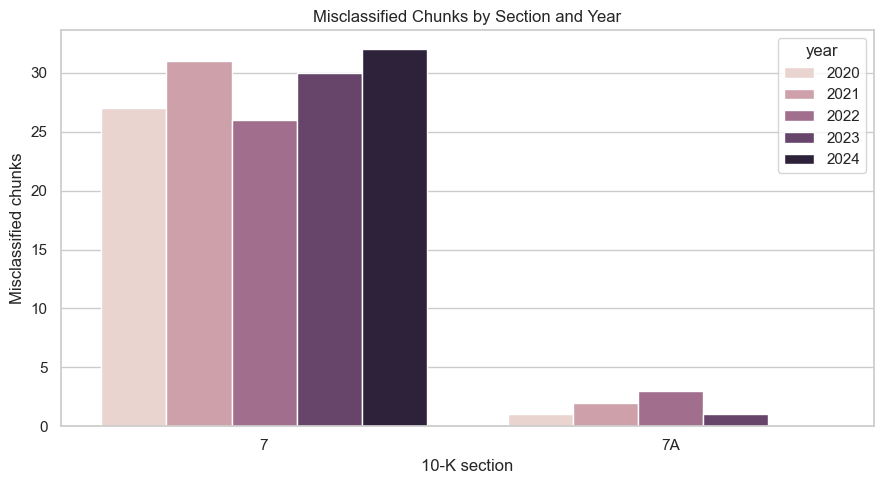

In [22]:

if not misclassified_df.empty:
    misclassification_summary_df = (
        misclassified_df.groupby(["item", "year"])
        .size()
        .rename("misclassified_chunks")
        .reset_index()
    )
    display(misclassification_summary_df)

    plt.figure(figsize=(9, 5))
    sns.barplot(data=misclassification_summary_df, x="item", y="misclassified_chunks", hue="year")
    plt.title("Misclassified Chunks by Section and Year")
    plt.xlabel("10-K section")
    plt.ylabel("Misclassified chunks")
    plt.tight_layout()
    plt.show()

    misclassification_summary_df.to_csv(ASSIGNMENT_DIR / "misclassification_summary.csv", index=False)
else:
    print("No misclassified chunks were found in this run.")


# Q1: Which Section Best Separates the Two Rivals?

For Q1, retrain the same classifier separately on Item 7, Item 7A, and Item 8. The point is not just to report the best accuracy, but to interpret what that section says about how the firms differentiate their language.


,item,accuracy,n_chunks
1,7A,1.000000,334
0,7,0.939306,1728
2,8,NaN,2463


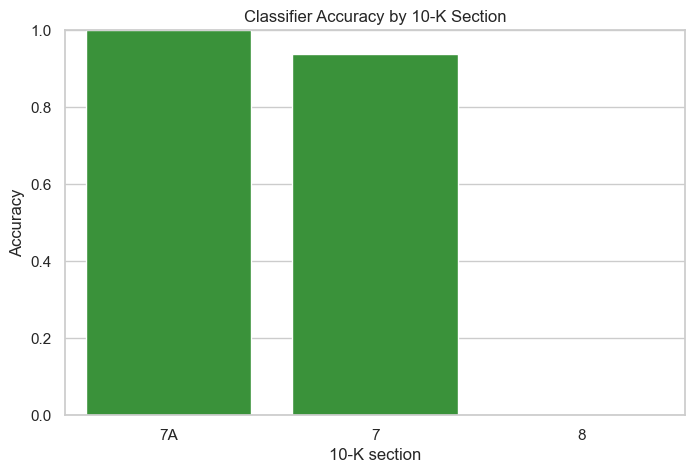

In [23]:
section_results = []

for item in TARGET_ITEMS:
    subset = chunks_df[chunks_df["item"] == item].copy()
    if subset["company"].nunique() < 2 or len(subset) < 10:
        section_results.append({"item": item, "accuracy": np.nan, "n_chunks": len(subset)})
        continue

    item_vectorizer = TfidfVectorizer(
        max_features=5000,
        stop_words="english",
        ngram_range=(1, 2),
        min_df=2,
    )
    X_item = item_vectorizer.fit_transform(subset["chunk_text"])
    y_item = make_labels(subset)
    item_run = train_bow_classifier(X_item, y_item)
    section_results.append(
        {
            "item": item,
            "accuracy": item_run["accuracy"],
            "n_chunks": len(subset),
        }
    )

section_results_df = pd.DataFrame(section_results).sort_values("accuracy", ascending=False)
display(section_results_df)

plt.figure(figsize=(8, 5))
sns.barplot(data=section_results_df, x="item", y="accuracy", color="#2ca02c")
plt.title("Classifier Accuracy by 10-K Section")
plt.xlabel("10-K section")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

section_results_df.to_csv(ASSIGNMENT_DIR / "section_accuracy_results.csv", index=False)



## Q1 Interpretation Prompt

Use the `section_results_df` table, the section-accuracy bar chart, the cosine-similarity outputs, and the corpus review visuals together.

In the student report, answer:

- Which of Item 7, Item 7A, or Item 8 produced the highest classification accuracy?
- Does the winning section also look more linguistically distinct in the cosine-similarity review?
- Is the result likely driven by real narrative differences, or by section-length / coverage differences that should be acknowledged as a limitation?


# Q2 and Q3 Write-Up Prompts

Use the outputs above to answer the assignment questions in the Word report.

## Q2

Discuss whether the neural bag-of-words classifier outperformed the cosine baseline in a meaningful way.

- If the gap is large, explain what that suggests about learnable vocabulary patterns.
- If the gap is small, explain whether the two firms are already separable with simpler similarity logic.
- Use the misclassified chunks to point out at least three failure modes or ambiguous cases.

## Q3

Use the top-term chart and the Yahoo Finance table together.

- Identify at least two terms that align with a numeric metric.
- Identify at least one term that adds business meaning not visible in the market table alone.
- End with a portfolio or monitoring recommendation that is consistent with both the text and the numbers.


In [24]:

q3_review_df = market_df[[
    "company",
    "ticker",
    "marketCap",
    "revenueGrowth",
    "returnOnEquity",
    "debtToEquity",
    "five_year_cumulative_return",
]].copy()
q3_review_df["top_term_examples"] = q3_review_df["company"].map(
    lambda company: ", ".join(top_terms_df.loc[top_terms_df["company"] == company, "term"].head(5).tolist())
)
display(q3_review_df)

q3_review_df.to_csv(ASSIGNMENT_DIR / "q3_business_review_table.csv", index=False)


,company,ticker,marketCap,revenueGrowth,returnOnEquity,debtToEquity,five_year_cumulative_return,top_term_examples
0,Microsoft,MSFT,3134205460480,0.183,0.34014,30.271,0.793383,"services, revenue, products, tax, cloud"
1,Oracle,ORCL,554933092352,0.217,0.57572,415.265,1.610609,"oracle, cloud, license, revenues, hardware"



## Business Recommendation Prompt

Use the market table, top-term charts, cosine-similarity outputs, classifier results, and misclassification review together.

In the student report, make sure the final recommendation addresses all of these:

- Which narrative signals align with the financial metrics?
- Which narrative signals add information the market table does not directly show?
- Would you overweight one company, underweight one company, or treat them as close substitutes?
- What is one limitation and one next-step analysis you would recommend before making a real investment decision?


# Deliverables Checklist {.unnumbered}

Artifacts this notebook should create in the local output folder:

- `company_context.csv`
- `company_context_missingness.csv`
- `filings_manifest.csv`
- `filings_year_coverage.csv`
- `corpus.csv`
- `extraction_log.csv`
- `corpus_section_coverage.csv`
- `corpus_char_summary.csv`
- `chunks.csv`
- `chunk_summary.csv`
- `tfidf_matrix.csv`
- `top_terms_by_company.csv`
- `cosine_similarity_by_year_item.csv`
- `classification_results.csv`
- `misclassified_chunks.csv`
- `section_accuracy_results.csv`
- `vocab.json`
- `bow_classifier_weights.pt`

Final submission reminder:

- The Word report should contain the final narrative answers and figures.
- The notebook should contain the executable evidence and saved artifacts.
- The AI disclosure should list tools used, prompts, outputs used, and validation steps.
